# Notebook 04: Comprehensive Evaluation on TEST SET

## Binary DR Detection — APTOS 2019 (EfficientNet-B3)

This notebook performs an **exhaustive evaluation** of the trained binary DR detection model on the **held-out test set** (never seen during training or validation).

| Section | Content |
|---|---|
| 1–2 | Imports, configuration, model loading |
| 3 | Test set inference |
| 4 | Core metrics + bootstrap 95% CIs |
| 5 | ROC curve with clinical operating points |
| 6 | Precision–Recall curve |
| 7 | Confusion matrix (optimal & clinical thresholds) |
| 8 | Threshold sensitivity analysis |
| 9 | Calibration analysis |
| 10 | Subgroup analysis by DR grade |
| 11 | Error analysis (misclassified cases) |
| 12 | Summary dashboard & export |

**Model:** EfficientNet-B3 (ImageNet → frozen head → full fine-tune)  
**Test set:** 531 APTOS 2019 images (stratified 15% hold-out)  
**Primary metric:** AUC-ROC  

---

## 1. Imports & Configuration

In [3]:
# ============================================================
# 1. Imports & Configuration
# ============================================================
import os, gc, json, warnings, random
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    accuracy_score, confusion_matrix, classification_report,
    cohen_kappa_score, matthews_corrcoef, f1_score,
    precision_score, recall_score, balanced_accuracy_score,
    log_loss, brier_score_loss,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

# ── Reproducibility ──
SEED = 42
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
set_seed(SEED)

# ── Device ──
def get_device() -> torch.device:
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

# ── Paths ──
ROOT = Path(".")
SPLITS_DIR = ROOT / "splits_aptos"
MODELS_DIR = ROOT / "models"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Model config (must match training) ──
CONFIG = {
    "model_name": "efficientnet_b3",
    "image_size": 384,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "dropout_rate": 0.4,
    "num_classes": 1,
    "batch_size": 16,
    "num_workers": 0,
    "pin_memory": False,
    "bootstrap_n": 2000,
}

# ── Plot style ──
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
PALETTE = {"no_dr": "#27ae60", "dr": "#c0392b", "blue": "#2980b9",
           "orange": "#e67e22", "purple": "#8e44ad", "gray": "#7f8c8d"}

print(f"Device           : {DEVICE}")
print(f"Model            : {CONFIG['model_name']}")
print(f"Image size       : {CONFIG['image_size']}\u00d7{CONFIG['image_size']}")
print(f"Bootstrap samples: {CONFIG['bootstrap_n']}")
print(f"Splits dir       : {SPLITS_DIR}")
print(f"Model checkpoint : {MODELS_DIR / 'best_binary_model.pth'}")
print("Configuration loaded \u2713")

Device           : mps
Model            : efficientnet_b3
Image size       : 384×384
Bootstrap samples: 2000
Splits dir       : splits_aptos
Model checkpoint : models/best_binary_model.pth
Configuration loaded ✓


In [1]:
print("he")

he


## 2. Load Model & Test Set

In [5]:
# ============================================================
# 2a. Load best binary model
# ============================================================
ckpt_path = MODELS_DIR / "best_binary_model.pth"
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

print(f"Checkpoint keys: {list(checkpoint.keys())}")
print(f"Best val AUC   : {checkpoint.get('best_val_auc', 'N/A')}")
print(f"Trained epoch  : {checkpoint.get('epoch', 'N/A')}")

# Reconstruct model
model = timm.create_model(CONFIG["model_name"], pretrained=False)
n_features = model.num_features  # 1536
model.classifier = nn.Sequential(
    nn.Dropout(p=CONFIG["dropout_rate"]),
    nn.Linear(n_features, 1),
)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel loaded    : {CONFIG['model_name']} ({total_params:,} params)")
print(f"Device          : {DEVICE}")
print("\u2713 Model ready for inference")

Checkpoint keys: ['model_name', 'num_features', 'dropout_rate', 'num_classes', 'image_size', 'mean', 'std', 'model_state_dict', 'best_val_auc', 'config']
Best val AUC   : 0.9957834757834757
Trained epoch  : N/A

Model loaded    : efficientnet_b3 (10,697,769 params)
Device          : mps
✓ Model ready for inference


In [7]:
# ============================================================
# 2b. Load test split & create DataLoader
# ============================================================
from torch.utils.data import Dataset, DataLoader

df_test = pd.read_csv(SPLITS_DIR / "test_split.csv")
print(f"Test set: {len(df_test)} images")
print(f"\nBinary distribution:")
print(df_test["binary_label"].value_counts().sort_index().to_string())
print(f"\nDR grade distribution:")
print(df_test["dr_grade"].value_counts().sort_index().to_string())

# Verify all files exist
missing = [p for p in df_test["preprocessed_path"] if not (ROOT / p).exists()]
assert len(missing) == 0, f"{len(missing)} files missing!"
print(f"\nAll {len(df_test)} files verified \u2713")


class DRDataset(Dataset):
    def __init__(self, dataframe, transform, root=Path(".")):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.root = root

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(str(self.root / row["preprocessed_path"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)["image"]
        label = torch.tensor([row["binary_label"]], dtype=torch.float32)
        return img, label


val_tfm = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.Normalize(mean=CONFIG["mean"], std=CONFIG["std"]),
    ToTensorV2(),
])

test_ds = DRDataset(df_test, val_tfm, ROOT)
test_loader = DataLoader(
    test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"],
)

print(f"\nDataLoader: {len(test_ds)} images \u2192 {len(test_loader)} batches")
print("\u2713 Test set ready")

Test set: 531 images

Binary distribution:
binary_label
0    270
1    261

DR grade distribution:
dr_grade
0    270
1     58
2    144
3     22
4     37

All 531 files verified ✓

DataLoader: 531 images → 34 batches
✓ Test set ready


## 3. Run Inference on Test Set

# Assistant
# Explanation of the Selected Code

This code performs inference (prediction) using a trained neural network model on test data. Here's a step-by-step breakdown:

1. The code starts with a comment section indicating this is the "Inference" part of the script.

2. Three empty lists are initialized to store labels, probabilities, and logits from the model predictions.

3. `with torch.no_grad():` creates a context where PyTorch doesn't track gradients, which speeds up inference and saves memory since we're not training.

4. A loop iterates through the `test_loader` with a progress bar (using `tqdm`):
   - Images are moved to the specified device (likely GPU)
   - The model generates logits (raw output scores) for each image
   - Sigmoid function converts logits to probability values between 0 and 1
   - Results are moved from GPU to CPU, converted to NumPy arrays, and stored in the lists

5. After the loop, the collected data is converted to NumPy arrays for analysis.

6. Finally, a summary of the inference results is printed, showing:
   - Total number of samples processed
   - Range of probability and logit values
   - Distribution of the two classes (0 and 1) in the test dataset

This code is typical for evaluating a binary classification model after training.

In [9]:
# ============================================================
# 3. Inference
# ============================================================
all_labels, all_probs, all_logits = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test inference"):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs = torch.sigmoid(logits)
        all_logits.extend(logits.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(labels.numpy().flatten())

y_true = np.array(all_labels, dtype=int)
y_prob = np.array(all_probs)
y_logit = np.array(all_logits)

print(f"\nInference complete:")
print(f"  Samples    : {len(y_true)}")
print(f"  Prob range : [{y_prob.min():.6f}, {y_prob.max():.6f}]")
print(f"  Logit range: [{y_logit.min():.4f}, {y_logit.max():.4f}]")
print(f"  Class 0    : {(y_true == 0).sum()} ({(y_true == 0).mean()*100:.1f}%)")
print(f"  Class 1    : {(y_true == 1).sum()} ({(y_true == 1).mean()*100:.1f}%)")

Test inference: 100%|███████████████████████████| 34/34 [00:08<00:00,  4.02it/s]


Inference complete:
  Samples    : 531
  Prob range : [0.000000, 1.000000]
  Logit range: [-22.6449, 18.6996]
  Class 0    : 270 (50.8%)
  Class 1    : 261 (49.2%)


## 4. Core Metrics with Bootstrap 95% Confidence Intervals

# Assistant
The selected code handles the calculation of high-specificity operating point values and prints a comprehensive set of binary classification metrics. Here's a step-by-step explanation:

1. The first part sets high-specificity values:
   - If a high-specificity threshold was found earlier, it uses those values
   - Otherwise, it falls back to using the optimal threshold values

2. The majority of the code creates a formatted report displaying:
   - Model information and test set details
   - The optimal threshold and Youden's J statistic
   - Various classification metrics with their values and confidence intervals where available
   - The confusion matrix components (TP, TN, FP, FN)
   - Clinical operating points for high-sensitivity and high-specificity scenarios

The code uses Unicode characters for special symbols and carefully formats the output with consistent spacing and alignment to create a professional-looking performance report.

In [11]:
# ============================================================
# 4. Core metrics + bootstrap CIs
# ============================================================

def bootstrap_ci(y_true, y_score, metric_fn, n_boot=2000, ci=95, seed=42):
    """Bootstrap confidence interval for any metric function."""
    rng = np.random.RandomState(seed)
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            scores.append(metric_fn(y_true[idx], y_score[idx]))
        except Exception:
            continue
    alpha = (100 - ci) / 2
    return np.percentile(scores, alpha), np.percentile(scores, 100 - alpha)


# ── ROC & optimal threshold ──
fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
auc_roc = roc_auc_score(y_true, y_prob)

# Youden's J statistic
J = tpr - fpr
opt_idx = np.argmax(J)
opt_threshold = thresholds_roc[opt_idx]

# ── PR curve ──
prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_true, y_prob)
auc_pr = auc(rec_curve, prec_curve)

# ── Predictions at optimal threshold ──
y_pred = (y_prob >= opt_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# ── Compute all metrics ──
metrics = {
    "AUC-ROC": auc_roc,
    "AUC-PR": auc_pr,
    "Accuracy": accuracy_score(y_true, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    "Sensitivity (Recall)": tp / (tp + fn),
    "Specificity": tn / (tn + fp),
    "Precision (PPV)": tp / (tp + fp),
    "NPV": tn / (tn + fn),
    "F1-Score": f1_score(y_true, y_pred),
    "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
    "MCC": matthews_corrcoef(y_true, y_pred),
    "Brier Score": brier_score_loss(y_true, y_prob),
    "Log Loss": log_loss(y_true, y_prob),
}

# ── Bootstrap CIs ──
N_BOOT = CONFIG["bootstrap_n"]

ci_auc_roc = bootstrap_ci(y_true, y_prob, roc_auc_score, N_BOOT)

def _acc(yt, yp): return accuracy_score(yt, (yp >= opt_threshold).astype(int))
def _sens(yt, yp):
    yp_ = (yp >= opt_threshold).astype(int)
    return recall_score(yt, yp_, zero_division=0)
def _spec(yt, yp):
    yp_ = (yp >= opt_threshold).astype(int)
    return recall_score(yt, yp_, pos_label=0, zero_division=0)
def _f1(yt, yp): return f1_score(yt, (yp >= opt_threshold).astype(int), zero_division=0)
def _auc_pr(yt, yp):
    p, r, _ = precision_recall_curve(yt, yp)
    return auc(r, p)

ci_acc = bootstrap_ci(y_true, y_prob, _acc, N_BOOT)
ci_sens = bootstrap_ci(y_true, y_prob, _sens, N_BOOT)
ci_spec = bootstrap_ci(y_true, y_prob, _spec, N_BOOT)
ci_f1 = bootstrap_ci(y_true, y_prob, _f1, N_BOOT)
ci_auc_pr = bootstrap_ci(y_true, y_prob, _auc_pr, N_BOOT)

# ── Clinical operating points ──
# High-sensitivity (\u2265 0.95)
hi_sens_mask = tpr >= 0.95
if hi_sens_mask.any():
    hi_sens_idx = np.where(hi_sens_mask)[0]
    # Pick the point with highest specificity among those with sens >= 0.95
    best_hi_sens = hi_sens_idx[np.argmin(fpr[hi_sens_idx])]
    hi_sens_thresh = thresholds_roc[best_hi_sens]
    hi_sens_spec = 1 - fpr[best_hi_sens]
    hi_sens_sens = tpr[best_hi_sens]
else:
    hi_sens_thresh, hi_sens_spec, hi_sens_sens = opt_threshold, metrics["Specificity"], metrics["Sensitivity (Recall)"]

# High-specificity (\u2265 0.95)
hi_spec_mask = (1 - fpr) >= 0.95
if hi_spec_mask.any():
    hi_spec_idx = np.where(hi_spec_mask)[0]
    # Pick the point with highest sensitivity among those with spec >= 0.95
    best_hi_spec = hi_spec_idx[np.argmax(tpr[hi_spec_idx])]
    hi_spec_thresh = thresholds_roc[best_hi_spec]
    hi_spec_sens = tpr[best_hi_spec]
    hi_spec_spec = 1 - fpr[best_hi_spec]
else:
    hi_spec_thresh, hi_spec_sens, hi_spec_spec = opt_threshold, metrics["Sensitivity (Recall)"], metrics["Specificity"]

# ── Print ──
print("=" * 70)
print("BINARY CLASSIFICATION \u2014 TEST SET RESULTS (APTOS 2019)")
print("=" * 70)
print(f"  Model             : {CONFIG['model_name']}")
print(f"  Test samples      : {len(y_true)}")
print(f"  Optimal threshold : {opt_threshold:.4f} (Youden\u2019s J = {J[opt_idx]:.4f})")
print()
print(f"  {'Metric':<25s} {'Value':>10s}  {'95% CI':>20s}")
print(f"  {'-'*58}")
print(f"  {'AUC-ROC':<25s} {auc_roc:>10.4f}  [{ci_auc_roc[0]:.4f}, {ci_auc_roc[1]:.4f}]")
print(f"  {'AUC-PR':<25s} {auc_pr:>10.4f}  [{ci_auc_pr[0]:.4f}, {ci_auc_pr[1]:.4f}]")
print(f"  {'Accuracy':<25s} {metrics['Accuracy']:>10.4f}  [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]")
print(f"  {'Balanced Accuracy':<25s} {metrics['Balanced Accuracy']:>10.4f}")
print(f"  {'Sensitivity (Recall)':<25s} {metrics['Sensitivity (Recall)']:>10.4f}  [{ci_sens[0]:.4f}, {ci_sens[1]:.4f}]")
print(f"  {'Specificity':<25s} {metrics['Specificity']:>10.4f}  [{ci_spec[0]:.4f}, {ci_spec[1]:.4f}]")
print(f"  {'Precision (PPV)':<25s} {metrics['Precision (PPV)']:>10.4f}")
print(f"  {'NPV':<25s} {metrics['NPV']:>10.4f}")
print(f"  {'F1-Score':<25s} {metrics['F1-Score']:>10.4f}  [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}]")
print(f"  {'Cohen\u2019s Kappa':<25s} {metrics["Cohen's Kappa"]:>10.4f}")
print(f"  {'MCC':<25s} {metrics['MCC']:>10.4f}")
print(f"  {'Brier Score':<25s} {metrics['Brier Score']:>10.4f}")
print(f"  {'Log Loss':<25s} {metrics['Log Loss']:>10.4f}")
print()
print(f"  Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print()
print(f"  Clinical Operating Points:")
print(f"    High-sensitivity (\u2265 0.95): thresh={hi_sens_thresh:.4f}, sens={hi_sens_sens:.4f}, spec={hi_sens_spec:.4f}")
print(f"    High-specificity (\u2265 0.95): thresh={hi_spec_thresh:.4f}, sens={hi_spec_sens:.4f}, spec={hi_spec_spec:.4f}")

BINARY CLASSIFICATION — TEST SET RESULTS (APTOS 2019)
  Model             : efficientnet_b3
  Test samples      : 531
  Optimal threshold : 0.4706 (Youden’s J = 0.9812)

  Metric                         Value                95% CI
  ----------------------------------------------------------
  AUC-ROC                       0.9992  [0.9979, 1.0000]
  AUC-PR                        0.9992  [0.9979, 0.9999]
  Accuracy                      0.9906  [0.9812, 0.9981]
  Balanced Accuracy             0.9906
  Sensitivity (Recall)          0.9923  [0.9805, 1.0000]
  Specificity                   0.9889  [0.9750, 1.0000]
  Precision (PPV)               0.9885
  NPV                           0.9926
  F1-Score                      0.9904  [0.9814, 0.9981]
  Cohen’s Kappa                 0.9812
  MCC                           0.9812
  Brier Score                   0.0093
  Log Loss                      0.0359

  Confusion Matrix: TP=259, TN=267, FP=3, FN=2

  Clinical Operating Points:
    High-sensit

## 5. ROC Curve with Clinical Operating Points

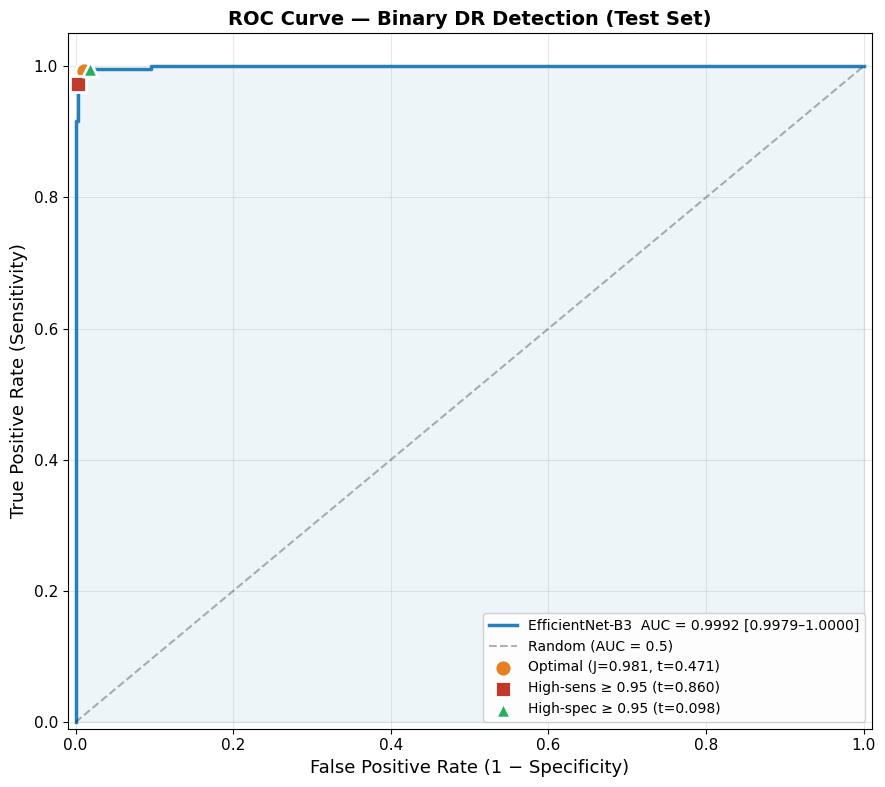

Saved → figures/eval_roc_curve.png


In [13]:
# ============================================================
# 5. ROC curve
# ============================================================
fig, ax = plt.subplots(figsize=(9, 8))

# Main ROC
ax.plot(fpr, tpr, color=PALETTE["blue"], lw=2.5,
        label=f'EfficientNet-B3  AUC = {auc_roc:.4f} [{ci_auc_roc[0]:.4f}\u2013{ci_auc_roc[1]:.4f}]')
ax.fill_between(fpr, tpr, alpha=0.08, color=PALETTE["blue"])

# Diagonal
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.5)')

# Operating points
ax.scatter(fpr[opt_idx], tpr[opt_idx], color=PALETTE["orange"], s=150,
           zorder=5, edgecolors='white', linewidth=2,
           label=f'Optimal (J={J[opt_idx]:.3f}, t={opt_threshold:.3f})')

if hi_sens_mask.any():
    ax.scatter(fpr[best_hi_sens], tpr[best_hi_sens], color=PALETTE["dr"], s=120,
               marker='s', zorder=5, edgecolors='white', linewidth=2,
               label=f'High-sens \u2265 0.95 (t={hi_sens_thresh:.3f})')

if hi_spec_mask.any():
    ax.scatter(fpr[best_hi_spec], tpr[best_hi_spec], color=PALETTE["no_dr"], s=120,
               marker='^', zorder=5, edgecolors='white', linewidth=2,
               label=f'High-spec \u2265 0.95 (t={hi_spec_thresh:.3f})')

ax.set_xlabel('False Positive Rate (1 \u2212 Specificity)', fontsize=13)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=13)
ax.set_title('ROC Curve \u2014 Binary DR Detection (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])

plt.tight_layout()
plt.savefig(FIG_DIR / "eval_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {FIG_DIR / 'eval_roc_curve.png'}")

## 6. Precision–Recall Curve

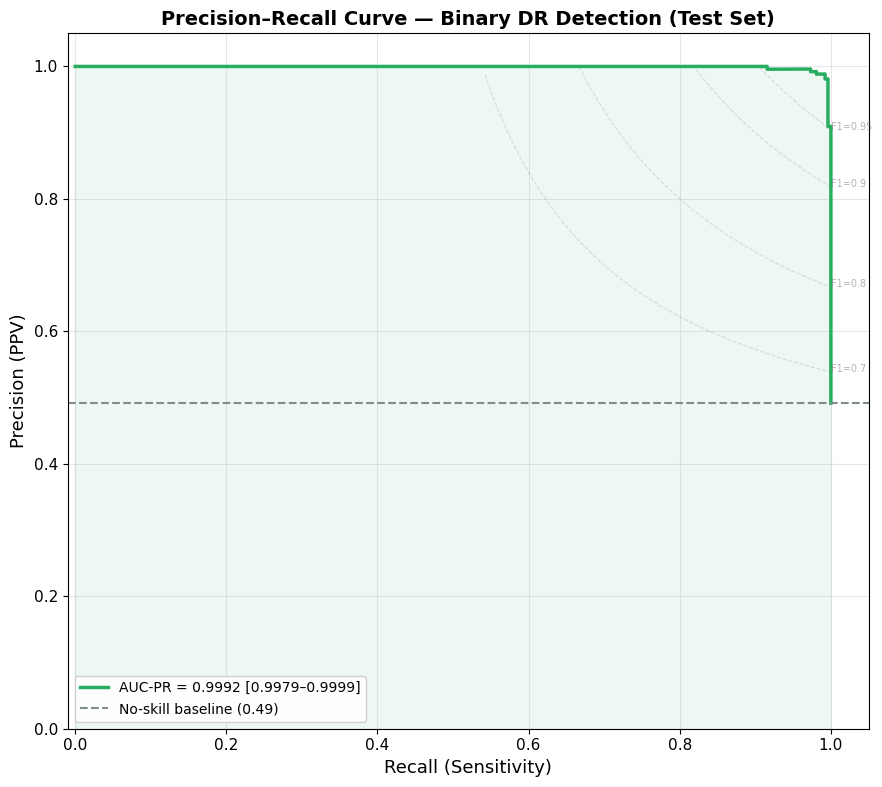

Saved → figures/eval_pr_curve.png


In [15]:
# ============================================================
# 6. Precision-Recall curve
# ============================================================
fig, ax = plt.subplots(figsize=(9, 8))

ax.plot(rec_curve, prec_curve, color=PALETTE["no_dr"], lw=2.5,
        label=f'AUC-PR = {auc_pr:.4f} [{ci_auc_pr[0]:.4f}\u2013{ci_auc_pr[1]:.4f}]')
ax.fill_between(rec_curve, prec_curve, alpha=0.08, color=PALETTE["no_dr"])

# Baseline (prevalence)
prevalence = y_true.mean()
ax.axhline(y=prevalence, color=PALETTE["gray"], ls='--', lw=1.5,
           label=f'No-skill baseline ({prevalence:.2f})')

# Mark F1-iso curves
for f1_val in [0.7, 0.8, 0.9, 0.95]:
    r_ = np.linspace(0.01, 1, 200)
    p_ = f1_val * r_ / (2 * r_ - f1_val)
    valid = (p_ > 0) & (p_ <= 1)
    ax.plot(r_[valid], p_[valid], '--', color='gray', alpha=0.25, lw=0.8)
    # label at right end
    if valid.any():
        idx_ = np.where(valid)[0][-1]
        ax.annotate(f'F1={f1_val}', (r_[idx_], p_[idx_]), fontsize=7, color='gray', alpha=0.6)

ax.set_xlabel('Recall (Sensitivity)', fontsize=13)
ax.set_ylabel('Precision (PPV)', fontsize=13)
ax.set_title('Precision\u2013Recall Curve \u2014 Binary DR Detection (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.set_xlim([-0.01, 1.05])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(FIG_DIR / "eval_pr_curve.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {FIG_DIR / 'eval_pr_curve.png'}")

## 7. Confusion Matrices (Optimal & Clinical Thresholds)

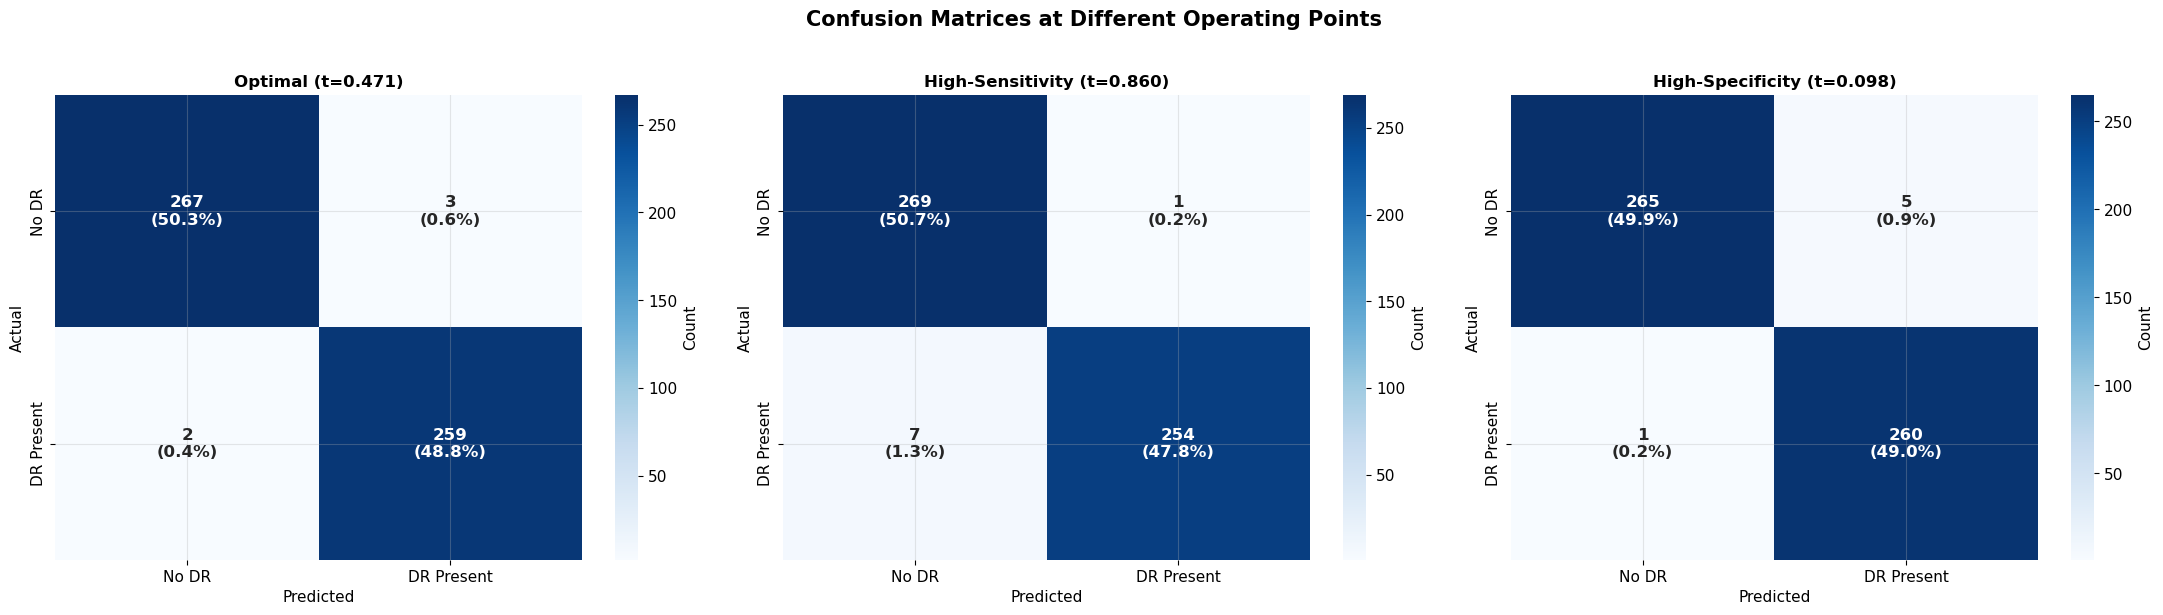

Saved → figures/eval_confusion_matrices.png


In [17]:
# ============================================================
# 7. Confusion matrices at multiple thresholds
# ============================================================
def plot_cm(y_true, y_pred, ax, title, labels=["No DR", "DR Present"]):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm / cm.sum() * 100
    annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=ax,
                xticklabels=labels, yticklabels=labels,
                cbar_kws={"label": "Count"}, annot_kws={"size": 12, "weight": "bold"})
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")


fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Confusion Matrices at Different Operating Points",
             fontsize=15, fontweight="bold", y=1.02)

# Optimal threshold
plot_cm(y_true, (y_prob >= opt_threshold).astype(int), axes[0],
        f"Optimal (t={opt_threshold:.3f})")

# High-sensitivity threshold
plot_cm(y_true, (y_prob >= hi_sens_thresh).astype(int), axes[1],
        f"High-Sensitivity (t={hi_sens_thresh:.3f})")

# High-specificity threshold
plot_cm(y_true, (y_prob >= hi_spec_thresh).astype(int), axes[2],
        f"High-Specificity (t={hi_spec_thresh:.3f})")

plt.tight_layout()
plt.savefig(FIG_DIR / "eval_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {FIG_DIR / 'eval_confusion_matrices.png'}")

## 8. Threshold Sensitivity Analysis

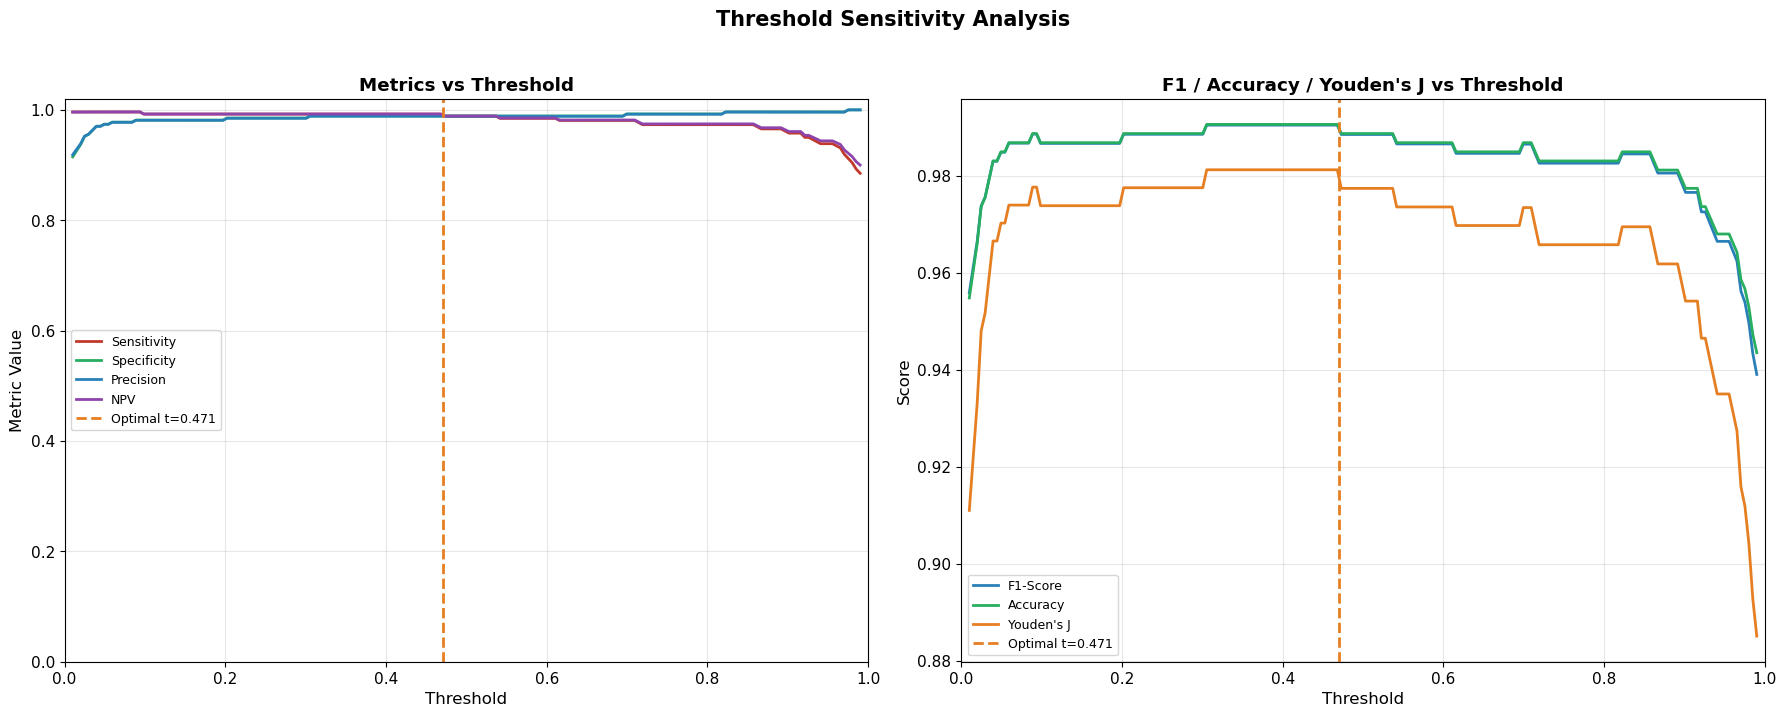

Saved → figures/eval_threshold_analysis.png


In [19]:
# ============================================================
# 8. Threshold sensitivity analysis
# ============================================================
thresholds_sweep = np.linspace(0.01, 0.99, 200)
sweep_metrics = {"threshold": [], "sensitivity": [], "specificity": [],
                 "precision": [], "npv": [], "f1": [], "accuracy": [], "youden_j": []}

for t in thresholds_sweep:
    yp = (y_prob >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_true, yp).ravel()
    sens_ = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
    spec_ = tn_ / (tn_ + fp_) if (tn_ + fp_) > 0 else 0
    prec_ = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    npv_ = tn_ / (tn_ + fn_) if (tn_ + fn_) > 0 else 0
    f1_ = 2 * prec_ * sens_ / (prec_ + sens_) if (prec_ + sens_) > 0 else 0
    acc_ = (tp_ + tn_) / len(y_true)
    sweep_metrics["threshold"].append(t)
    sweep_metrics["sensitivity"].append(sens_)
    sweep_metrics["specificity"].append(spec_)
    sweep_metrics["precision"].append(prec_)
    sweep_metrics["npv"].append(npv_)
    sweep_metrics["f1"].append(f1_)
    sweep_metrics["accuracy"].append(acc_)
    sweep_metrics["youden_j"].append(sens_ + spec_ - 1)

df_sweep = pd.DataFrame(sweep_metrics)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Threshold Sensitivity Analysis", fontsize=15, fontweight="bold", y=1.02)

# Panel A: Sensitivity vs Specificity trade-off
ax = axes[0]
ax.plot(df_sweep["threshold"], df_sweep["sensitivity"], lw=2, label="Sensitivity", color=PALETTE["dr"])
ax.plot(df_sweep["threshold"], df_sweep["specificity"], lw=2, label="Specificity", color=PALETTE["no_dr"])
ax.plot(df_sweep["threshold"], df_sweep["precision"], lw=2, label="Precision", color=PALETTE["blue"])
ax.plot(df_sweep["threshold"], df_sweep["npv"], lw=2, label="NPV", color=PALETTE["purple"])
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls="--", lw=2,
           label=f"Optimal t={opt_threshold:.3f}")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Metric Value", fontsize=12)
ax.set_title("Metrics vs Threshold", fontweight="bold")
ax.legend(fontsize=9, loc="center left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Panel B: F1 + Accuracy + Youden's J
ax = axes[1]
ax.plot(df_sweep["threshold"], df_sweep["f1"], lw=2, label="F1-Score", color=PALETTE["blue"])
ax.plot(df_sweep["threshold"], df_sweep["accuracy"], lw=2, label="Accuracy", color=PALETTE["no_dr"])
ax.plot(df_sweep["threshold"], df_sweep["youden_j"], lw=2, label="Youden's J", color=PALETTE["orange"])
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls="--", lw=2,
           label=f"Optimal t={opt_threshold:.3f}")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("F1 / Accuracy / Youden's J vs Threshold", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim([0, 1])

plt.tight_layout()
plt.savefig(FIG_DIR / "eval_threshold_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {FIG_DIR / 'eval_threshold_analysis.png'}")

## 9. Calibration Analysis

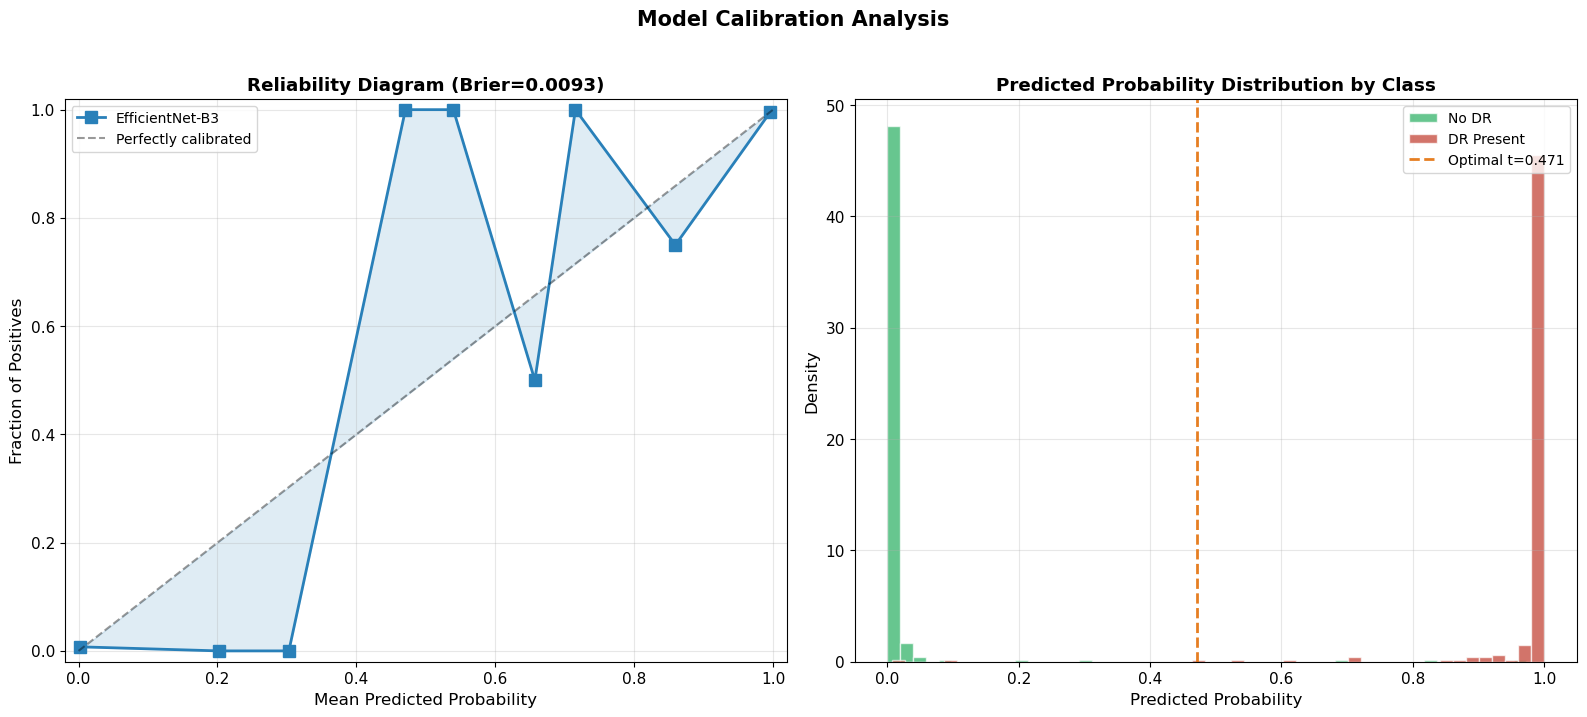

Saved → figures/eval_calibration.png


In [21]:
# ============================================================
# 9. Calibration analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Model Calibration Analysis", fontsize=15, fontweight="bold", y=1.02)

# ── 9a. Reliability diagram ──
ax = axes[0]
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')

ax.plot(prob_pred, prob_true, 's-', color=PALETTE["blue"], lw=2, markersize=8,
        label='EfficientNet-B3')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')

# Shade the gap
ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color=PALETTE["blue"])

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title(f'Reliability Diagram (Brier={metrics["Brier Score"]:.4f})', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# ── 9b. Prediction histogram ──
ax = axes[1]
ax.hist(y_prob[y_true == 0], bins=50, alpha=0.7, color=PALETTE["no_dr"],
        label='No DR', density=True, edgecolor='white')
ax.hist(y_prob[y_true == 1], bins=50, alpha=0.7, color=PALETTE["dr"],
        label='DR Present', density=True, edgecolor='white')
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls='--', lw=2,
           label=f'Optimal t={opt_threshold:.3f}')
ax.set_xlabel('Predicted Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Predicted Probability Distribution by Class', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "eval_calibration.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {FIG_DIR / 'eval_calibration.png'}")

## 10. Subgroup Analysis by DR Grade

SUBGROUP ANALYSIS BY ORIGINAL DR GRADE

  Grade                    N   Binary  Mean Prob      Acc   Errors
  --------------------------------------------------------------
  No DR                  270        0     0.0134   0.9889        3
  Mild                    58        1     0.9323   0.9655        2
  Moderate               144        1     0.9922   1.0000        0
  Severe                  22        1     0.9999   1.0000        0
  Proliferative           37        1     0.9972   1.0000        0


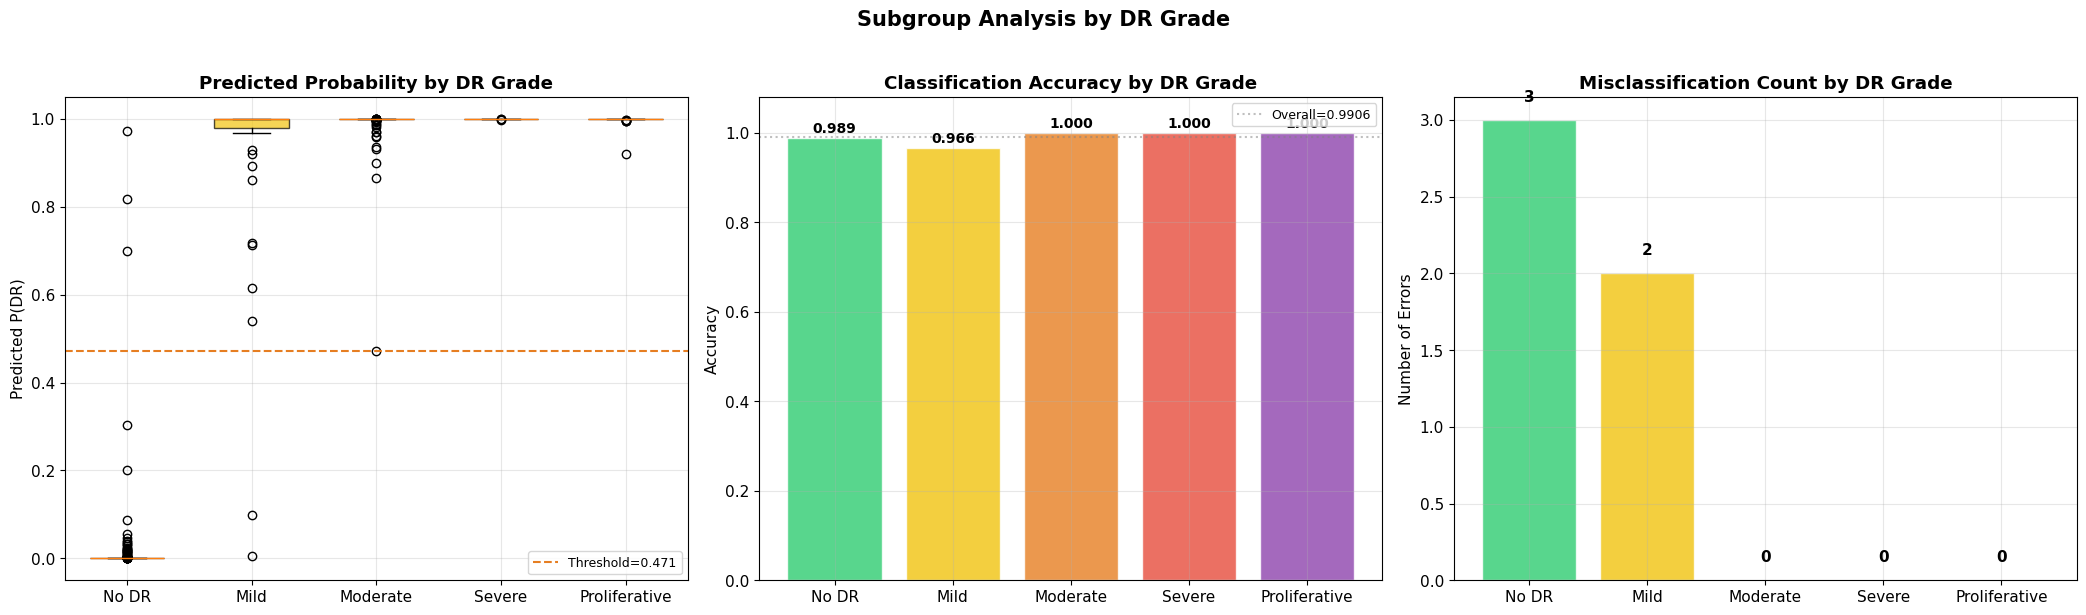

Saved → figures/eval_subgroup_analysis.png


In [23]:
# ============================================================
# 10. Subgroup analysis by original DR grade
# ============================================================
grade_names = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative"}
grade_colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

df_analysis = df_test.copy()
df_analysis["y_prob"] = y_prob
df_analysis["y_pred"] = y_pred
df_analysis["correct"] = (df_analysis["binary_label"] == df_analysis["y_pred"]).astype(int)

print("=" * 70)
print("SUBGROUP ANALYSIS BY ORIGINAL DR GRADE")
print("=" * 70)
print(f"\n  {'Grade':<20s} {'N':>5s} {'Binary':>8s} {'Mean Prob':>10s} {'Acc':>8s} {'Errors':>8s}")
print(f"  {'-'*62}")

subgroup_stats = []
for grade in sorted(df_analysis["dr_grade"].unique()):
    sub = df_analysis[df_analysis["dr_grade"] == grade]
    n = len(sub)
    binary = int(sub["binary_label"].iloc[0])
    mean_prob = sub["y_prob"].mean()
    acc = sub["correct"].mean()
    errors = (sub["correct"] == 0).sum()
    subgroup_stats.append({"grade": grade, "name": grade_names[grade], "n": n,
                           "binary": binary, "mean_prob": mean_prob, "acc": acc, "errors": errors})
    print(f"  {grade_names[grade]:<20s} {n:>5d} {binary:>8d} {mean_prob:>10.4f} {acc:>8.4f} {errors:>8d}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("Subgroup Analysis by DR Grade", fontsize=15, fontweight="bold", y=1.02)

# Panel A: Predicted probability by grade
ax = axes[0]
grade_data = [df_analysis[df_analysis["dr_grade"] == g]["y_prob"].values
              for g in range(5) if g in df_analysis["dr_grade"].values]
grade_labels = [grade_names[g] for g in range(5) if g in df_analysis["dr_grade"].values]
bp = ax.boxplot(grade_data, labels=grade_labels, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], grade_colors[:len(grade_data)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=opt_threshold, color=PALETTE["orange"], ls='--', lw=1.5,
           label=f'Threshold={opt_threshold:.3f}')
ax.set_ylabel('Predicted P(DR)', fontsize=11)
ax.set_title('Predicted Probability by DR Grade', fontweight='bold')
ax.legend(fontsize=9)

# Panel B: Accuracy per grade
ax = axes[1]
names = [s["name"] for s in subgroup_stats]
accs = [s["acc"] for s in subgroup_stats]
colors = [grade_colors[s["grade"]] for s in subgroup_stats]
bars = ax.bar(names, accs, color=colors, edgecolor='white', alpha=0.8)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{a:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Classification Accuracy by DR Grade', fontweight='bold')
ax.set_ylim([0, 1.08])
ax.axhline(y=metrics["Accuracy"], color='gray', ls=':', alpha=0.5, label=f'Overall={metrics["Accuracy"]:.4f}')
ax.legend(fontsize=9)

# Panel C: Error count per grade
ax = axes[2]
errs = [s["errors"] for s in subgroup_stats]
bars = ax.bar(names, errs, color=colors, edgecolor='white', alpha=0.8)
for bar, e in zip(bars, errs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(e), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Errors', fontsize=11)
ax.set_title('Misclassification Count by DR Grade', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / "eval_subgroup_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {FIG_DIR / 'eval_subgroup_analysis.png'}")

## 11. Error Analysis — Misclassified Cases

ERROR ANALYSIS

  Total errors: 5 / 531 (0.9%)
  False Positives (No DR predicted as DR): 3
  False Negatives (DR predicted as No DR): 2

  False Negatives by DR grade:
    Grade 1 (Mild): 2/58 (3.4%)


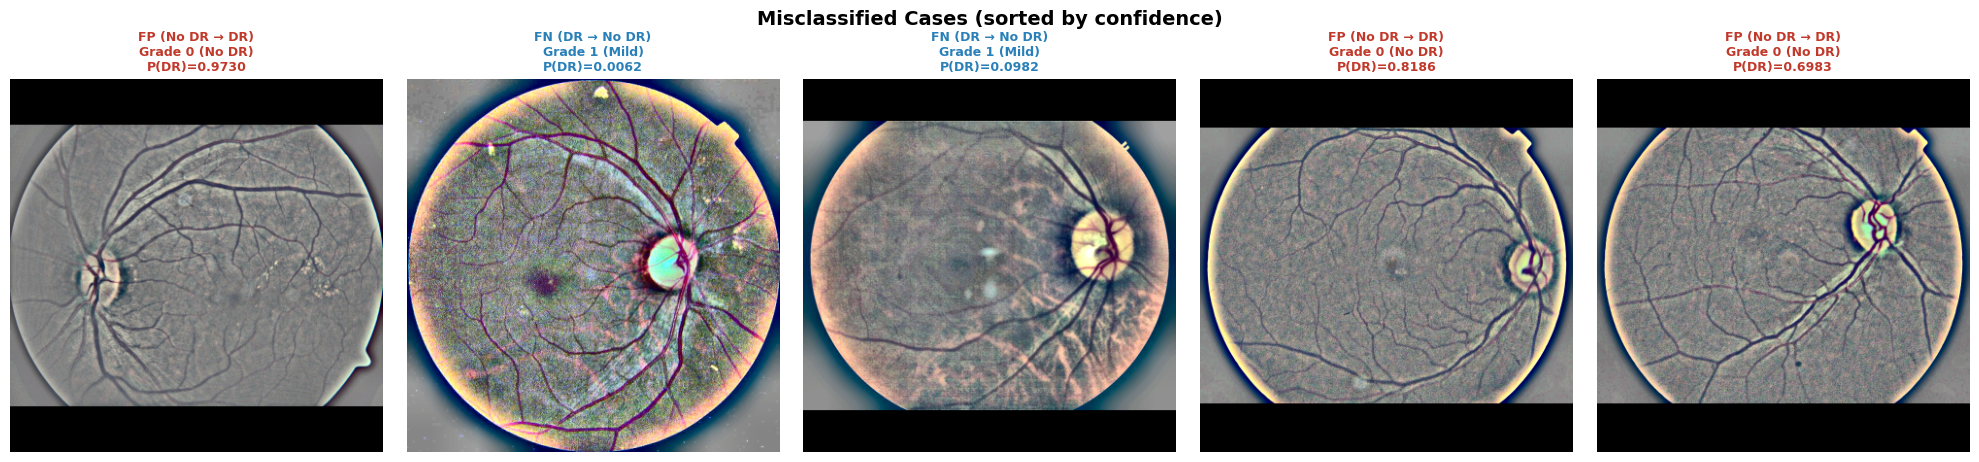

Saved → figures/eval_error_analysis.png


In [25]:
# ============================================================
# 11. Error analysis
# ============================================================
df_errors = df_analysis[df_analysis["correct"] == 0].copy()
df_errors["error_type"] = df_errors.apply(
    lambda r: "FP (No DR \u2192 DR)" if r["binary_label"] == 0 else "FN (DR \u2192 No DR)", axis=1
)

print("=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)
print(f"\n  Total errors: {len(df_errors)} / {len(df_analysis)} ({len(df_errors)/len(df_analysis)*100:.1f}%)")
print(f"  False Positives (No DR predicted as DR): {fp}")
print(f"  False Negatives (DR predicted as No DR): {fn}")

print(f"\n  False Negatives by DR grade:")
fn_by_grade = df_errors[df_errors["binary_label"] == 1]["dr_grade"].value_counts().sort_index()
for grade, count in fn_by_grade.items():
    total_grade = len(df_analysis[(df_analysis["dr_grade"] == grade)])
    print(f"    Grade {grade} ({grade_names[grade]}): {count}/{total_grade} ({count/total_grade*100:.1f}%)")

# Show misclassified images
n_show = min(len(df_errors), 10)
if n_show > 0:
    # Sort by confidence (most confident errors first)
    df_errors_sorted = df_errors.copy()
    df_errors_sorted["confidence"] = np.abs(df_errors_sorted["y_prob"] - opt_threshold)
    df_errors_sorted = df_errors_sorted.sort_values("confidence", ascending=False)

    n_cols = min(n_show, 5)
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
    fig.suptitle("Misclassified Cases (sorted by confidence)",
                 fontsize=14, fontweight="bold", y=1.02)
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_rows * n_cols):
        r, c = i // n_cols, i % n_cols
        ax = axes[r, c]
        if i < n_show:
            row = df_errors_sorted.iloc[i]
            img = cv2.imread(str(ROOT / row["preprocessed_path"]))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            color = PALETTE["dr"] if row["error_type"].startswith("FP") else PALETTE["blue"]
            ax.set_title(f"{row['error_type']}\nGrade {int(row['dr_grade'])} ({grade_names[int(row['dr_grade'])]})\n"
                         f"P(DR)={row['y_prob']:.4f}",
                         fontsize=9, color=color, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(FIG_DIR / "eval_error_analysis.png", dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved \u2192 {FIG_DIR / 'eval_error_analysis.png'}")
else:
    print("\n  No misclassified cases! Perfect classification on test set.")

## 12. Summary Dashboard & Export

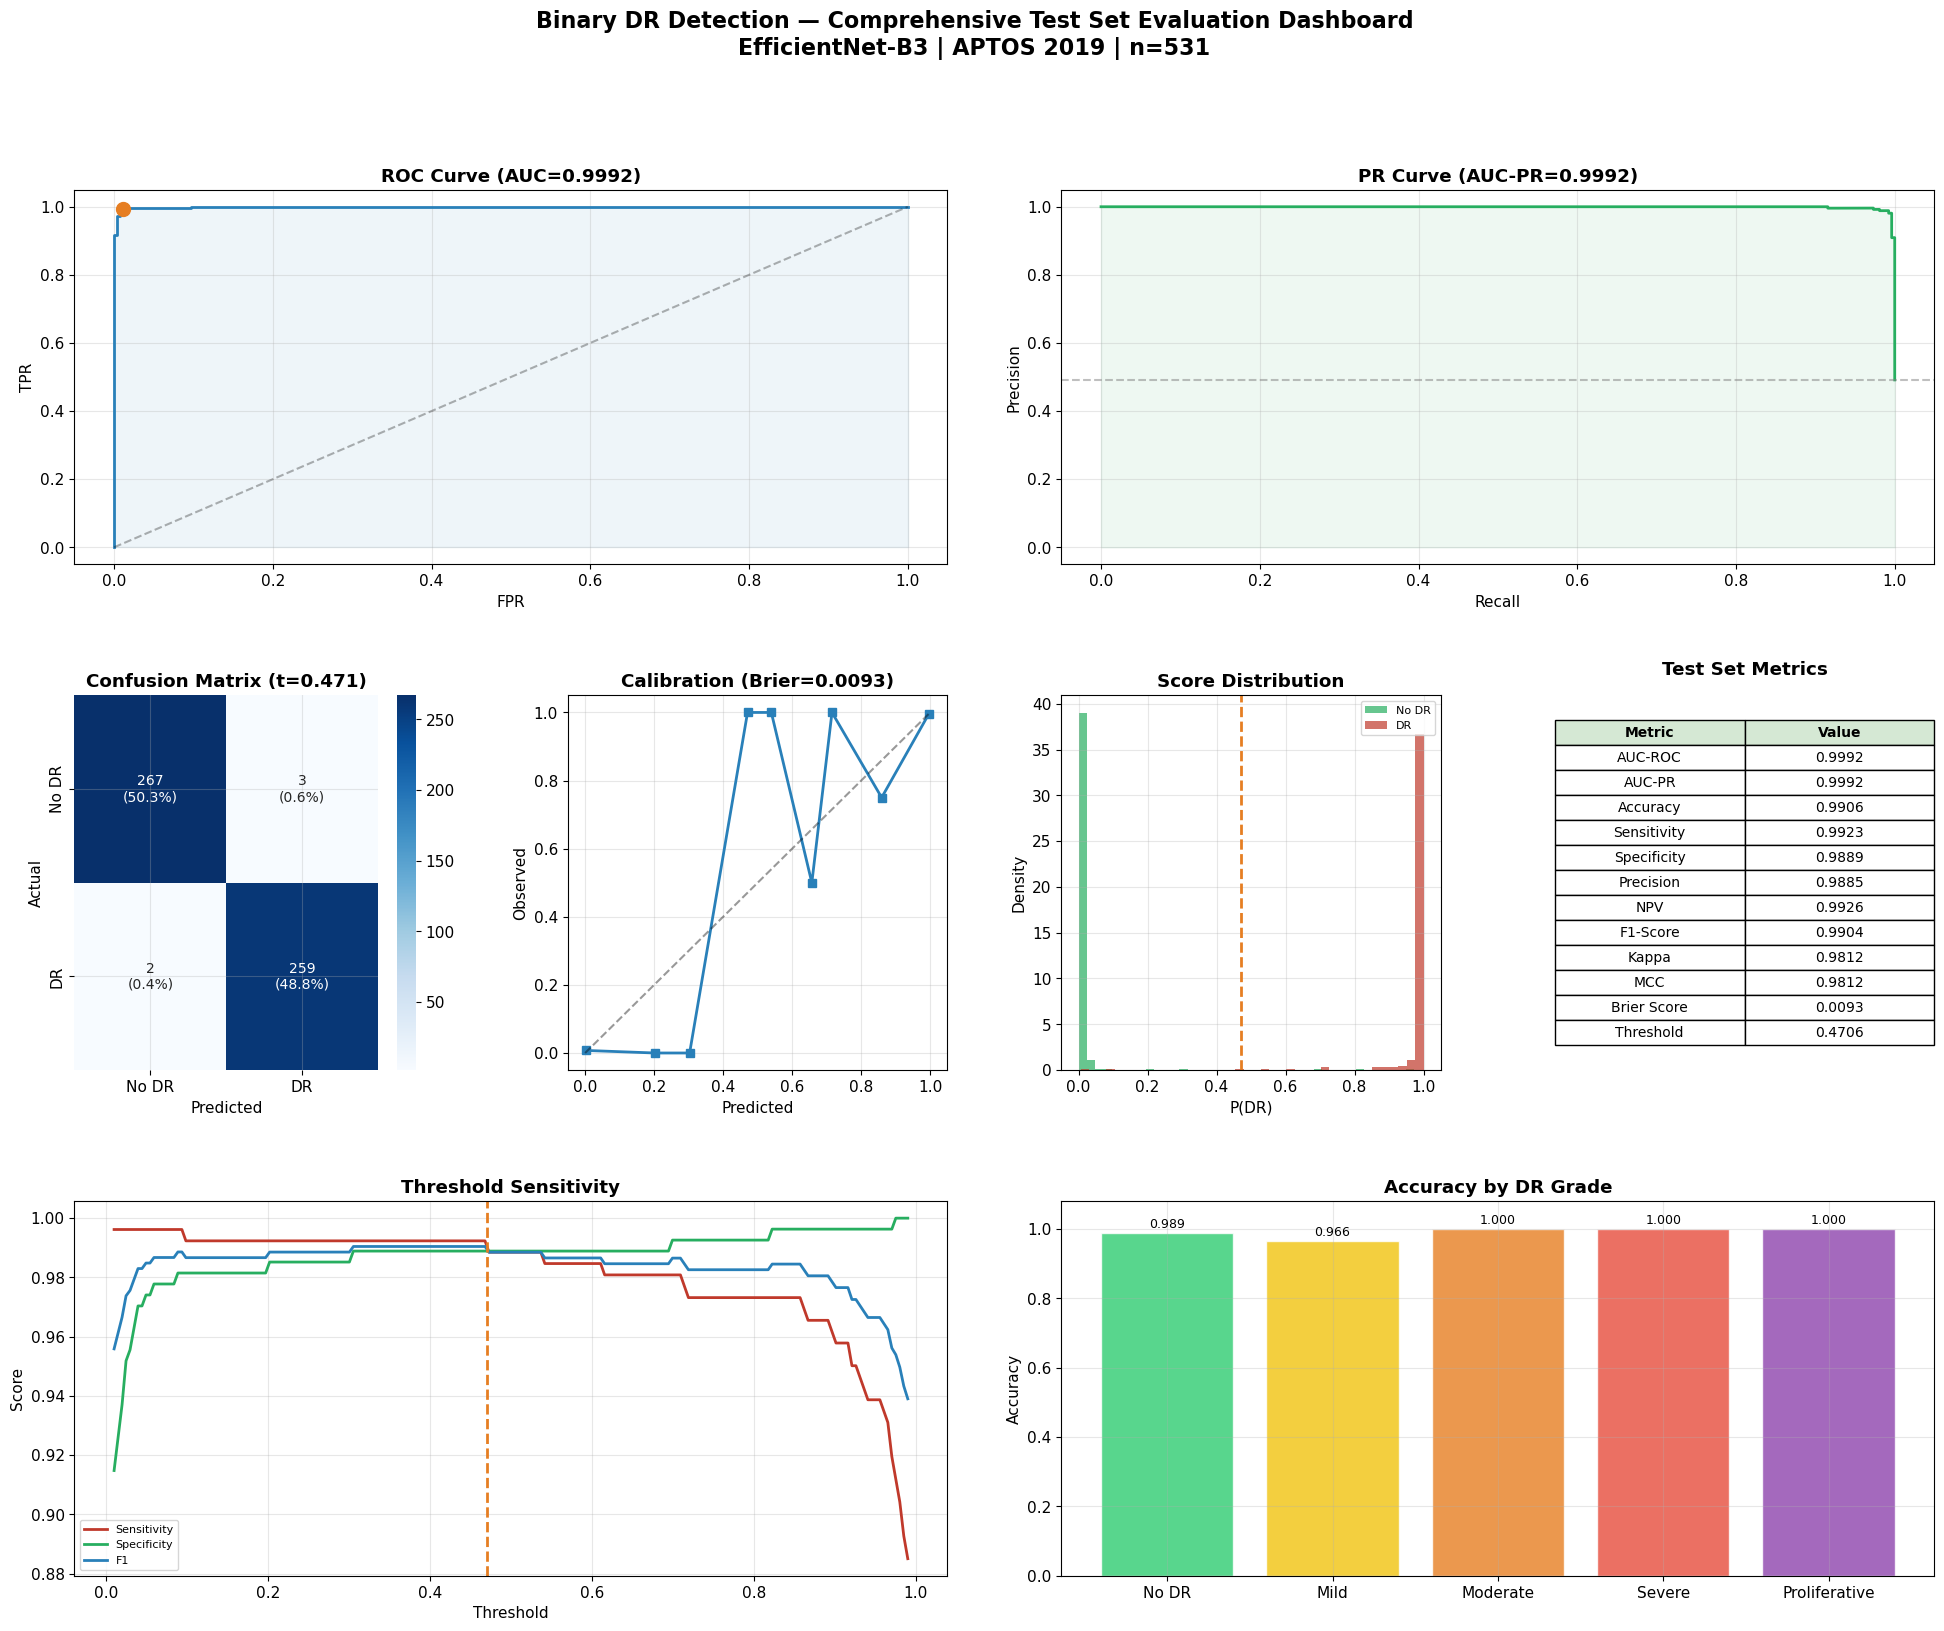

Saved → figures/eval_dashboard.png


In [27]:
# ============================================================
# 12a. Summary dashboard figure
# ============================================================
fig = plt.figure(figsize=(24, 18))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)
fig.suptitle("Binary DR Detection \u2014 Comprehensive Test Set Evaluation Dashboard\n"
             f"EfficientNet-B3 | APTOS 2019 | n={len(y_true)}",
             fontsize=16, fontweight="bold", y=0.98)

# ── (0,0-1) ROC Curve ──
ax = fig.add_subplot(gs[0, 0:2])
ax.plot(fpr, tpr, color=PALETTE["blue"], lw=2)
ax.fill_between(fpr, tpr, alpha=0.08, color=PALETTE["blue"])
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.scatter(fpr[opt_idx], tpr[opt_idx], color=PALETTE["orange"], s=100, zorder=5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC Curve (AUC={auc_roc:.4f})', fontweight='bold')

# ── (0,2-3) PR Curve ──
ax = fig.add_subplot(gs[0, 2:4])
ax.plot(rec_curve, prec_curve, color=PALETTE["no_dr"], lw=2)
ax.fill_between(rec_curve, prec_curve, alpha=0.08, color=PALETTE["no_dr"])
ax.axhline(y=prevalence, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'PR Curve (AUC-PR={auc_pr:.4f})', fontweight='bold')

# ── (1,0) Confusion Matrix ──
ax = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm / cm.sum() * 100
annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=ax,
            xticklabels=["No DR", "DR"], yticklabels=["No DR", "DR"],
            annot_kws={"size": 10})
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (t={opt_threshold:.3f})', fontweight='bold')

# ── (1,1) Calibration ──
ax = fig.add_subplot(gs[1, 1])
ax.plot(prob_pred, prob_true, 's-', color=PALETTE["blue"], lw=2, markersize=6)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('Predicted'); ax.set_ylabel('Observed')
ax.set_title(f'Calibration (Brier={metrics["Brier Score"]:.4f})', fontweight='bold')

# ── (1,2) Probability histogram ──
ax = fig.add_subplot(gs[1, 2])
ax.hist(y_prob[y_true == 0], bins=40, alpha=0.7, color=PALETTE["no_dr"], label='No DR', density=True)
ax.hist(y_prob[y_true == 1], bins=40, alpha=0.7, color=PALETTE["dr"], label='DR', density=True)
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls='--', lw=2)
ax.set_xlabel('P(DR)'); ax.set_ylabel('Density')
ax.set_title('Score Distribution', fontweight='bold')
ax.legend(fontsize=8)

# ── (1,3) Metrics table ──
ax = fig.add_subplot(gs[1, 3])
ax.axis('off')
table_data = [
    ['AUC-ROC', f'{auc_roc:.4f}'],
    ['AUC-PR', f'{auc_pr:.4f}'],
    ['Accuracy', f'{metrics["Accuracy"]:.4f}'],
    ['Sensitivity', f'{metrics["Sensitivity (Recall)"]:.4f}'],
    ['Specificity', f'{metrics["Specificity"]:.4f}'],
    ['Precision', f'{metrics["Precision (PPV)"]:.4f}'],
    ['NPV', f'{metrics["NPV"]:.4f}'],
    ['F1-Score', f'{metrics["F1-Score"]:.4f}'],
    ['Kappa', f'{metrics["Cohen\'s Kappa"]:.4f}'],
    ['MCC', f'{metrics["MCC"]:.4f}'],
    ['Brier Score', f'{metrics["Brier Score"]:.4f}'],
    ['Threshold', f'{opt_threshold:.4f}'],
]
table = ax.table(cellText=table_data, colLabels=['Metric', 'Value'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#d5e8d4')
ax.set_title('Test Set Metrics', fontweight='bold', pad=15)

# ── (2,0-1) Threshold analysis ──
ax = fig.add_subplot(gs[2, 0:2])
ax.plot(df_sweep["threshold"], df_sweep["sensitivity"], lw=2, label="Sensitivity", color=PALETTE["dr"])
ax.plot(df_sweep["threshold"], df_sweep["specificity"], lw=2, label="Specificity", color=PALETTE["no_dr"])
ax.plot(df_sweep["threshold"], df_sweep["f1"], lw=2, label="F1", color=PALETTE["blue"])
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls='--', lw=2)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity', fontweight='bold')
ax.legend(fontsize=8)

# ── (2,2-3) Subgroup analysis ──
ax = fig.add_subplot(gs[2, 2:4])
grade_present = sorted(df_analysis["dr_grade"].unique())
names_present = [grade_names[g] for g in grade_present]
accs_present = [df_analysis[df_analysis["dr_grade"] == g]["correct"].mean() for g in grade_present]
colors_present = [grade_colors[g] for g in grade_present]
bars = ax.bar(names_present, accs_present, color=colors_present, edgecolor='white', alpha=0.8)
for bar, a in zip(bars, accs_present):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{a:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by DR Grade', fontweight='bold')
ax.set_ylim([0, 1.08])

plt.savefig(FIG_DIR / "eval_dashboard.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {FIG_DIR / 'eval_dashboard.png'}")

In [29]:
# ============================================================
# 12b. Export all metrics to JSON
# ============================================================
export_metrics = {
    "dataset": "APTOS 2019",
    "task": "binary_classification",
    "model": CONFIG["model_name"],
    "image_size": CONFIG["image_size"],
    "test_size": int(len(y_true)),
    "prevalence": float(prevalence),
    "optimal_threshold": float(opt_threshold),
    "youdens_j": float(J[opt_idx]),
    "metrics": {
        "auc_roc": {"value": float(auc_roc), "ci_lower": float(ci_auc_roc[0]), "ci_upper": float(ci_auc_roc[1])},
        "auc_pr": {"value": float(auc_pr), "ci_lower": float(ci_auc_pr[0]), "ci_upper": float(ci_auc_pr[1])},
        "accuracy": {"value": float(metrics["Accuracy"]), "ci_lower": float(ci_acc[0]), "ci_upper": float(ci_acc[1])},
        "balanced_accuracy": float(metrics["Balanced Accuracy"]),
        "sensitivity": {"value": float(metrics["Sensitivity (Recall)"]), "ci_lower": float(ci_sens[0]), "ci_upper": float(ci_sens[1])},
        "specificity": {"value": float(metrics["Specificity"]), "ci_lower": float(ci_spec[0]), "ci_upper": float(ci_spec[1])},
        "precision": float(metrics["Precision (PPV)"]),
        "npv": float(metrics["NPV"]),
        "f1_score": {"value": float(metrics["F1-Score"]), "ci_lower": float(ci_f1[0]), "ci_upper": float(ci_f1[1])},
        "cohen_kappa": float(metrics["Cohen's Kappa"]),
        "mcc": float(metrics["MCC"]),
        "brier_score": float(metrics["Brier Score"]),
        "log_loss": float(metrics["Log Loss"]),
    },
    "confusion_matrix": {"tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn)},
    "clinical_operating_points": {
        "high_sensitivity": {
            "threshold": float(hi_sens_thresh),
            "sensitivity": float(hi_sens_sens),
            "specificity": float(hi_sens_spec),
        },
        "high_specificity": {
            "threshold": float(hi_spec_thresh),
            "sensitivity": float(hi_spec_sens),
            "specificity": float(hi_spec_spec),
        },
    },
    "subgroup_analysis": subgroup_stats,
    "bootstrap_n": CONFIG["bootstrap_n"],
}

json_path = MODELS_DIR / "aptos_binary_comprehensive_eval.json"
with open(json_path, "w") as f:
    json.dump(export_metrics, f, indent=2, default=str)

print(f"Metrics exported \u2192 {json_path}")

# Also save predictions for downstream analysis
df_predictions = df_analysis[["image_id", "preprocessed_path", "dr_grade",
                              "binary_label", "y_prob", "y_pred", "correct"]].copy()
pred_path = MODELS_DIR / "aptos_binary_test_predictions.csv"
df_predictions.to_csv(pred_path, index=False)
print(f"Predictions saved \u2192 {pred_path}")

Metrics exported → models/aptos_binary_comprehensive_eval.json
Predictions saved → models/aptos_binary_test_predictions.csv


In [31]:
# ============================================================
# 13. Final Summary
# ============================================================
print("=" * 70)
print("COMPREHENSIVE EVALUATION \u2014 COMPLETE")
print("=" * 70)

print(f"\n  Model            : {CONFIG['model_name']}")
print(f"  Dataset          : APTOS 2019")
print(f"  Test samples     : {len(y_true)}")
print(f"  Optimal threshold: {opt_threshold:.4f}")

print(f"\n  \u250c{'\u2500'*44}\u2510")
print(f"  \u2502  AUC-ROC     : {auc_roc:.4f} [{ci_auc_roc[0]:.4f}, {ci_auc_roc[1]:.4f}]  \u2502")
print(f"  \u2502  AUC-PR      : {auc_pr:.4f} [{ci_auc_pr[0]:.4f}, {ci_auc_pr[1]:.4f}]  \u2502")
print(f"  \u2502  Accuracy    : {metrics['Accuracy']:.4f} [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]  \u2502")
print(f"  \u2502  Sensitivity : {metrics['Sensitivity (Recall)']:.4f} [{ci_sens[0]:.4f}, {ci_sens[1]:.4f}]  \u2502")
print(f"  \u2502  Specificity : {metrics['Specificity']:.4f} [{ci_spec[0]:.4f}, {ci_spec[1]:.4f}]  \u2502")
print(f"  \u2502  F1-Score    : {metrics['F1-Score']:.4f} [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}]  \u2502")
print(f"  \u2502  Kappa       : {metrics["Cohen's Kappa"]:.4f}                      \u2502")
print(f"  \u2502  Brier Score : {metrics['Brier Score']:.4f}                      \u2502")
print(f"  \u2514{'\u2500'*44}\u2518")

print(f"\n  Total errors: {len(df_errors)} / {len(y_true)} ({len(df_errors)/len(y_true)*100:.1f}%)")
print(f"    \u2022 False Positives: {fp}")
print(f"    \u2022 False Negatives: {fn}")

print(f"\n  Output files:")
output_files = [
    FIG_DIR / "eval_roc_curve.png",
    FIG_DIR / "eval_pr_curve.png",
    FIG_DIR / "eval_confusion_matrices.png",
    FIG_DIR / "eval_threshold_analysis.png",
    FIG_DIR / "eval_calibration.png",
    FIG_DIR / "eval_subgroup_analysis.png",
    FIG_DIR / "eval_error_analysis.png",
    FIG_DIR / "eval_dashboard.png",
    MODELS_DIR / "aptos_binary_comprehensive_eval.json",
    MODELS_DIR / "aptos_binary_test_predictions.csv",
]
for f in output_files:
    status = "\u2713" if f.exists() else "\u2717"
    print(f"    {status} {f}")

# Cleanup
del model
gc.collect()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
print("\nMemory cleaned up \u2713")

COMPREHENSIVE EVALUATION — COMPLETE

  Model            : efficientnet_b3
  Dataset          : APTOS 2019
  Test samples     : 531
  Optimal threshold: 0.4706

  ┌────────────────────────────────────────────┐
  │  AUC-ROC     : 0.9992 [0.9979, 1.0000]  │
  │  AUC-PR      : 0.9992 [0.9979, 0.9999]  │
  │  Accuracy    : 0.9906 [0.9812, 0.9981]  │
  │  Sensitivity : 0.9923 [0.9805, 1.0000]  │
  │  Specificity : 0.9889 [0.9750, 1.0000]  │
  │  F1-Score    : 0.9904 [0.9814, 0.9981]  │
  │  Kappa       : 0.9812                      │
  │  Brier Score : 0.0093                      │
  └────────────────────────────────────────────┘

  Total errors: 5 / 531 (0.9%)
    • False Positives: 3
    • False Negatives: 2

  Output files:
    ✓ figures/eval_roc_curve.png
    ✓ figures/eval_pr_curve.png
    ✓ figures/eval_confusion_matrices.png
    ✓ figures/eval_threshold_analysis.png
    ✓ figures/eval_calibration.png
    ✓ figures/eval_subgroup_analysis.png
    ✓ figures/eval_error_analysis.png
    ✓ 